In [46]:
import pandas as pd 

data = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
test_ids = test["PassengerId"]

In [ ]:
data

In [47]:
def clean(data):
    
    cols = ["SibSp", "Parch", "Fare", "Age"]
    classes = [1, 2, 3]

    for col in cols:
        for clas in classes:
            median = data.loc[data["Pclass"] == clas, col].median()

            data.loc[
                (data["Pclass"] == clas) & (data[col].isna()),
                col
            ] = median

    data["Embarked"] = data["Embarked"].fillna("U")

    return data

data = clean(data)
test = clean(test)

In [48]:
# feature engineer 
for df in [data,test]:
    df["family_size"] = df["Parch"] + df["SibSp"] + 1
    df["is_child"] = (df["Age"] < 14).astype(int)
    df["is_alone"] = (df["family_size"] == 1).astype(int)
    df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.")
    

In [49]:
data = data.drop(["Cabin","Name", "PassengerId"],axis=1)
test = test.drop(["Cabin","Name", "PassengerId"],axis=1)


In [50]:
print (data["Ticket"].nunique())

681


In [51]:
print(len(data))

891


In [52]:
ticket_counts = pd.concat([data["Ticket"], test["Ticket"]]).value_counts()
for df in [data, test]:
    df["TicketGroupSize"] = df["Ticket"].map(ticket_counts)

In [ ]:
data

In [53]:
data = data.drop("Ticket" , axis = 1)

In [54]:
agemean = data["Age"].mean()
agestd = data["Age"].std()
faremean = data["Fare"].mean()
farestd = data["Fare"].std()

data["Age"] = (data["Age"]-agemean)/agestd
test["Age"] = (test["Age"] - agemean) / agestd

data["Fare"] = (data["Fare"]-faremean)/farestd
test["Fare"] = (test["Fare"] - faremean) / farestd

In [ ]:
data

In [55]:
data["Sex"] = data["Sex"].map({"male": 0, "female": 1})
test["Sex"] = test["Sex"].map({"male": 0, "female": 1})
data = pd.get_dummies(data, columns=["Embarked","Pclass", "Title"], dtype=int)
test = pd.get_dummies(test, columns=["Embarked","Pclass", "Title"], dtype=int)

test = test.reindex(columns=data.drop("Survived", axis=1).columns, fill_value=0)

In [56]:
import numpy as np 
import matplotlib.pyplot as plt



In [ ]:
data

In [57]:
x_train = data.drop("Survived", axis = 1)
y_train = data["Survived"]

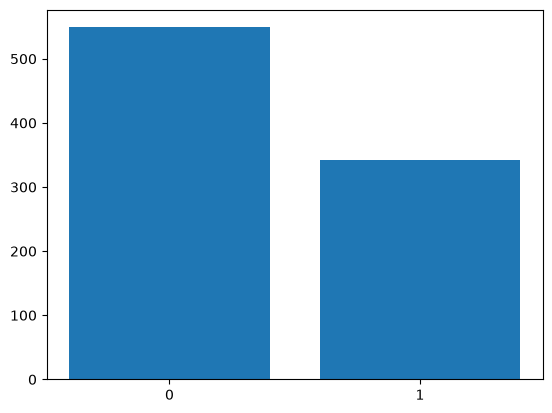

In [58]:
counts = np.bincount(y_train)
positions = np.arange(2)

plt.bar(positions, counts)
plt.xticks(positions, [0, 1])

plt.show()

In [ ]:
y_train

In [ ]:
notsurvived = x_train[y_train==0]
didsurvive = x_train[y_train == 1]

In [ ]:
notsurvived

In [ ]:
didsurvive

In [ ]:
perm0 = np.random.permutation(len(notsurvived))
perm1 = np.random.permutation(len(didsurvive))


dev0 = notsurvived.iloc[perm0[:100]]
dev1 = didsurvive.iloc[perm1[:20]]


x_dev = pd.concat([dev0, dev1])
y_dev = y_train.loc[x_dev.index]

x_train = x_train.drop(x_dev.index)
y_train = y_train.drop(y_dev.index)


In [60]:
from sklearn.model_selection import train_test_split

x_train, x_dev, y_train, y_dev = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [ ]:

counts = np.bincount(y_train)
positions = np.arange(2)

plt.bar(positions, counts)
plt.xticks(positions, [0, 1])

plt.show()

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt

counts = np.bincount(y_dev)
positions = np.arange(2)

plt.bar(positions, counts)
plt.xticks(positions, [0, 1])

plt.show()

In [66]:
import optuna

from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


def objective(trial):

    model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 400),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.1, log=True),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 6),

        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),

        gamma=trial.suggest_float("gamma", 0.0, 2.0),

        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 0.1, 5.0, log=True),

        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )

    score = cross_val_score(
        model,
        x_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    ).mean()

    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

print("Best CV accuracy:", study.best_value)
print("Best parameters:", study.best_params)

[I 2026-08-24 16:56:51,939] A new study created in memory with name: no-name-869b7bf6-a49d-4dff-b0c9-6d3d177c50df
[I 2026-08-24 16:56:52,077] Trial 0 finished with value: 0.8244459765586527 and parameters: {'n_estimators': 52, 'max_depth': 4, 'learning_rate': 0.07223326417906652, 'min_child_weight': 6, 'subsample': 0.8533084565953858, 'colsample_bytree': 0.9510334344548738, 'gamma': 1.41463998581263, 'reg_alpha': 0.08839181228778063, 'reg_lambda': 0.15790711326505708}. Best is trial 0 with value: 0.8244459765586527.
[I 2026-08-24 16:56:52,194] Trial 1 finished with value: 0.8174234216487737 and parameters: {'n_estimators': 63, 'max_depth': 2, 'learning_rate': 0.034235047370947624, 'min_child_weight': 6, 'subsample': 0.7726907711023596, 'colsample_bytree': 0.9657266641600463, 'gamma': 1.5157572663308623, 'reg_alpha': 0.000376739908499617, 'reg_lambda': 4.333334620912222}. Best is trial 0 with value: 0.8244459765586527.
[I 2026-08-24 16:56:52,544] Trial 2 finished with value: 0.830079779

Best CV accuracy: 0.8455530385107849
Best parameters: {'n_estimators': 394, 'max_depth': 4, 'learning_rate': 0.06872982080067376, 'min_child_weight': 1, 'subsample': 0.6996197442014356, 'colsample_bytree': 0.6445091173300034, 'gamma': 0.7261442740795775, 'reg_alpha': 0.024372071785321803, 'reg_lambda': 0.1027594937215698}


In [68]:
import pandas as pd 

df = study.trials_dataframe()

In [70]:
df.sort_values("value", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample,state
87,87,0.845553,2026-08-24 16:57:22.301175,2026-08-24 16:57:22.741506,0 days 00:00:00.440331,0.644509,0.726144,0.068730,4,1,394,0.024372,0.102759,0.699620,COMPLETE
191,191,0.844154,2026-08-24 16:58:09.608099,2026-08-24 16:58:10.101541,0 days 00:00:00.493442,0.641138,0.468544,0.079193,4,1,391,0.002806,1.420856,0.700618,COMPLETE
182,182,0.844154,2026-08-24 16:58:05.205527,2026-08-24 16:58:05.686108,0 days 00:00:00.480581,0.634213,0.478779,0.074111,4,1,400,0.009107,1.508559,0.707310,COMPLETE
137,137,0.844125,2026-08-24 16:57:44.366338,2026-08-24 16:57:44.775910,0 days 00:00:00.409572,0.905199,1.075464,0.075883,4,1,366,0.000397,0.128207,0.668452,COMPLETE
98,98,0.842726,2026-08-24 16:57:27.187414,2026-08-24 16:57:27.611106,0 days 00:00:00.423692,0.671907,0.804360,0.077631,4,2,387,0.038729,0.121497,0.743369,COMPLETE
194,194,0.841338,2026-08-24 16:58:11.106652,2026-08-24 16:58:11.671129,0 days 00:00:00.564477,0.620109,0.467296,0.078334,4,1,395,0.001658,1.418545,0.702767,COMPLETE
88,88,0.841338,2026-08-24 16:57:22.742552,2026-08-24 16:57:23.204024,0 days 00:00:00.461472,0.639182,0.612549,0.070576,4,1,392,0.035980,0.103134,0.705242,COMPLETE
152,152,0.841338,2026-08-24 16:57:51.107631,2026-08-24 16:57:51.603821,0 days 00:00:00.496190,0.641495,0.587718,0.069076,4,1,400,0.002412,1.385337,0.684966,COMPLETE
170,170,0.841328,2026-08-24 16:57:59.556203,2026-08-24 16:58:00.053650,0 days 00:00:00.497447,0.652529,0.432873,0.076931,4,1,400,0.003980,2.489174,0.713837,COMPLETE
129,129,0.841308,2026-08-24 16:57:41.068546,2026-08-24 16:57:41.438642,0 days 00:00:00.370096,0.911107,1.310131,0.069580,4,1,337,0.001060,0.100659,0.694281,COMPLETE


In [71]:
best_model = XGBClassifier(
    **study.best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

best_model.fit(x_train, y_train)

print("Dev accuracy:", best_model.score(x_dev, y_dev))

Dev accuracy: 0.8268156424581006


0.8100558659217877

In [73]:
submission_preds = best_model.predict(test)

In [74]:


df = pd.DataFrame({"PassengerId":test_ids.values, "Survived" : submission_preds })

df.to_csv("submissionxgboost.csv", index = False)